# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION
## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

## STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
**Group ID:** 102

**BITS ID:** 2024ac05014 |
**Name:** Arun A Pai |
**Email:** 2024ac05014@wilp.bits-pilani.ac.in |
**Date:** 16-02-2026 |
**Contribution:** 100% |


**BITS ID:** 2024ad05350 |
**Name:** DEEPTHY.A.N. |
**Email:** 2024ad05350@wilp.bits-pilani.ac.in |
**Date:** 16-02-2026 |
**Contribution:** 100% |


**BITS ID:** 2024ac05041 |
**Name:** SAMPATH KUMAR S SHETTY |
**Email:** 2024ac05041@wilp.bits-pilani.ac.in |
**Date:** 16-02-2026 |
**Contribution:** 100% |


**BITS ID:** 2024ad05344 |
**Name:** ANISH RADHAKRISHNAN SHOBHA KAITHASSERY |
**Email:** 2024ad05344@wilp.bits-pilani.ac.in |
**Date:** 16-02-2026 |
**Contribution:** 100% |

## ASSIGNMENT OVERVIEW

This assignment requires you to implement and compare two CNN approaches for image classification:
1. Custom CNN architecture using Keras/PyTorch
2. Transfer Learning using pre-trained models (ResNet/VGG)

**Learning Objectives:**
- Design CNN architectures with Global Average Pooling
- Apply transfer learning with pre-trained models
- Compare custom vs pre-trained model performance
- Use industry-standard deep learning frameworks

**IMPORTANT:** Global Average Pooling (GAP) is MANDATORY for both models.  
DO NOT use Flatten + Dense layers in the final architecture.

## Import Required Libraries

## Install PyTorch with CUDA Support

**IMPORTANT:** Run this cell only if you need to install/reinstall PyTorch with GPU support.

For different CUDA versions, visit: https://pytorch.org/get-started/locally/

In [43]:
# Uncomment and run ONE of the following based on your CUDA version:

# For CUDA 11.8 (Most common)
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# For CUDA 12.1
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# For CPU only (no GPU)
# !pip install torch torchvision torchaudio

# For Google Colab (already has PyTorch with CUDA)
# No installation needed - PyTorch is pre-installed

# Verify installation
import torch
print(f"PyTorch installed: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

PyTorch installed: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8


In [44]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import zipfile
import sys
import shutil


# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Image processing
from PIL import Image

# Device configuration - GPU support
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 70)
print("ENVIRONMENT SETUP")
print("=" * 70)
print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Available: Yes")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")
    # Enable cuDNN auto-tuner for better performance
    torch.backends.cudnn.benchmark = True
    print("cuDNN Auto-tuner: Enabled")
else:
    print(f"GPU Available: No (using CPU)")
    print("Note: Training will be slower on CPU")
print("=" * 70)

ENVIRONMENT SETUP
Python Version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
PyTorch Version: 2.9.0+cu128
Device: cuda
GPU Available: Yes
GPU Name: Tesla T4
GPU Memory: 14.56 GB
CUDA Version: 12.8
cuDNN Enabled: True
cuDNN Auto-tuner: Enabled


## PART 1: DATASET LOADING AND EXPLORATION

**Instructions:**
1. Choose ONE dataset from the allowed list
2. Load and explore the data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

**ALLOWED DATASETS:**
- Cats vs Dogs (2 classes)
- Food-101 subset (10-20 classes)
- Plant Disease (3-5 classes)
- Medical Images (2-3 classes)
- Custom dataset (with IC approval, min 500 images per class)

### 1.1 Dataset Selection and Loading

In [45]:
# 1.1 Dataset Selection and Loading

print("=" * 70)
print("DATASET SETUP")
print("=" * 70)

# Set download directory to current notebook location
DOWNLOAD_DIR = os.getcwd()
DATASET_PATH = os.path.join(DOWNLOAD_DIR, "new-plant-diseases-dataset")

# Auto-detect if dataset exists with different name
if not os.path.exists(DATASET_PATH):
    # Look for any folder containing train/valid folders (handles nested structure)
    for folder in os.listdir(DOWNLOAD_DIR):
        folder_path = os.path.join(DOWNLOAD_DIR, folder)
        if os.path.isdir(folder_path) and folder not in ['.git', '__pycache__', '.ipynb_checkpoints']:
            # Check direct level
            if os.path.exists(os.path.join(folder_path, "train")) and \
               os.path.exists(os.path.join(folder_path, "valid")):
                DATASET_PATH = folder_path
                break
            
            # Check nested level (e.g., "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/")
            try:
                subfolders = [d for d in os.listdir(folder_path) 
                             if os.path.isdir(os.path.join(folder_path, d))]
                for subfolder in subfolders:
                    subfolder_path = os.path.join(folder_path, subfolder)
                    if os.path.exists(os.path.join(subfolder_path, "train")) and \
                       os.path.exists(os.path.join(subfolder_path, "valid")):
                        DATASET_PATH = subfolder_path
                        break
                if os.path.exists(os.path.join(DATASET_PATH, "train")):
                    break
            except:
                pass

print(f"Location     : {DATASET_PATH}")

# Check if dataset already exists
if os.path.exists(DATASET_PATH):
    train_exists = os.path.exists(os.path.join(DATASET_PATH, "train"))
    valid_exists = os.path.exists(os.path.join(DATASET_PATH, "valid"))
    test_exists = os.path.exists(os.path.join(DATASET_PATH, "test"))
    
    # Check for test folder in parent directory (outside nested structure)
    test_path_alt = None
    if not test_exists and DATASET_PATH != DOWNLOAD_DIR:
        parent_dir = os.path.dirname(DATASET_PATH)
        test_path_candidate = os.path.join(parent_dir, "test")
        if os.path.exists(test_path_candidate):
            test_path_alt = test_path_candidate
            test_exists = True
    
    if train_exists and valid_exists:
        # Count classes
        train_dir = os.path.join(DATASET_PATH, "train")
        classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
        
        folders_status = "train/, valid/"
        if test_exists:
            if test_path_alt:
                folders_status += ", test/ (parent dir)"
            else:
                folders_status += ", test/"
        
        print(f"Status       : Ready")
        print(f"Classes      : {len(classes)}")
        print(f"Folders      : {folders_status}")
    else:
        print(f"Status       : Incomplete - Re-downloading...")
        shutil.rmtree(DATASET_PATH)
else:
    print(f"Status       : Not found - Starting download...")

print("=" * 70)

# Download if not exists
if not (os.path.exists(DATASET_PATH) and 
        os.path.exists(os.path.join(DATASET_PATH, "train")) and 
        os.path.exists(os.path.join(DATASET_PATH, "valid"))):
    
    try:
        # Install kaggle package
        print("Step 1: Installing Kaggle API...")
        import subprocess
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "kaggle"],
            capture_output=True,
            text=True,
            encoding='utf-8',
            errors='ignore'
        )
        print("[OK] Kaggle API installed")
        
        # Setup Kaggle credentials - UPDATED FOR PROPER AUTHENTICATION
        print("\nStep 2: Setting up Kaggle credentials...")
        
        # IMPORTANT: Replace these with your actual Kaggle credentials
        # Get them from: https://www.kaggle.com/settings/account → Create New API Token
        KAGGLE_USERNAME = "ARUN A. PAI"  # TODO: Replace with your Kaggle username
        KAGGLE_KEY = "KGAT_40f12bdae5e091dbde4d8da91a9ed785"  # TODO: Replace with your Kaggle API key
        
        # Create .kaggle directory
        kaggle_dir = os.path.join(os.path.expanduser("~"), ".kaggle")
        os.makedirs(kaggle_dir, exist_ok=True)
        
        # Create kaggle.json file with proper credentials
        kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
        kaggle_config = {
            "username": KAGGLE_USERNAME,
            "key": KAGGLE_KEY
        }
        
        with open(kaggle_json_path, 'w') as f:
            json.dump(kaggle_config, f)
        
        # Set file permissions (important for security)
        try:
            os.chmod(kaggle_json_path, 0o600)
        except:
            pass  # Windows doesn't support chmod
        
        print("[OK] Credentials configured")
        print(f"    Config file: {kaggle_json_path}")
        
        # Download dataset
        print("\nStep 3: Downloading dataset from Kaggle...")
        print("Dataset: vipoooool/new-plant-diseases-dataset")
        print("Size: ~2.5 GB (this may take several minutes)")
        print("Please wait...\n")
        
        result = subprocess.run(
            ["kaggle", "datasets", "download", "-d", 
             "vipoooool/new-plant-diseases-dataset", "-p", DOWNLOAD_DIR],
            capture_output=True,
            text=True,
            encoding='utf-8',
            errors='ignore'
        )
        
        if result.returncode == 0:
            print("[OK] Download completed successfully!")
            
            # Extract the zip file
            zip_path = os.path.join(DOWNLOAD_DIR, "new-plant-diseases-dataset.zip")
            
            if os.path.exists(zip_path):
                print(f"\nStep 4: Extracting dataset...")
                print(f"Extracting to: {DATASET_PATH}")
                
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    # Show progress
                    members = zip_ref.namelist()
                    total = len(members)
                    print(f"Total files to extract: {total}")
                    
                    for i, member in enumerate(members):
                        zip_ref.extract(member, DOWNLOAD_DIR)
                        if (i + 1) % 1000 == 0:
                            print(f"  Extracted {i + 1}/{total} files...")
                
                print("[OK] Extraction complete!")
                
                # Detect actual extracted folder name
                print("\nStep 5: Detecting extracted folder...")
                extracted_folders = [d for d in os.listdir(DOWNLOAD_DIR) 
                                   if os.path.isdir(os.path.join(DOWNLOAD_DIR, d)) 
                                   and d not in ['.git', '__pycache__', '.ipynb_checkpoints']]
                
                # Look for folder containing train/valid/test (handles nested structure)
                actual_dataset_path = None
                for folder in extracted_folders:
                    folder_path = os.path.join(DOWNLOAD_DIR, folder)
                    
                    # Check if train/valid are directly in this folder
                    if os.path.exists(os.path.join(folder_path, "train")) and \
                       os.path.exists(os.path.join(folder_path, "valid")):
                        actual_dataset_path = folder_path
                        print(f"[OK] Found dataset at: {folder}")
                        break
                    
                    # Check for nested folder (e.g., "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/")
                    subfolders = [d for d in os.listdir(folder_path) 
                                 if os.path.isdir(os.path.join(folder_path, d))]
                    for subfolder in subfolders:
                        subfolder_path = os.path.join(folder_path, subfolder)
                        if os.path.exists(os.path.join(subfolder_path, "train")) and \
                           os.path.exists(os.path.join(subfolder_path, "valid")):
                            actual_dataset_path = subfolder_path
                            print(f"[OK] Found dataset at: {folder}/{subfolder}")
                            break
                    
                    if actual_dataset_path:
                        break
                
                if actual_dataset_path:
                    DATASET_PATH = actual_dataset_path
                    print(f"[OK] Updated DATASET_PATH to: {DATASET_PATH}")
                
                # Clean up zip file
                print("\nStep 6: Cleaning up...")
                os.remove(zip_path)
                print("[OK] Zip file removed")
                
                # Verify structure
                train_check = os.path.exists(os.path.join(DATASET_PATH, "train"))
                valid_check = os.path.exists(os.path.join(DATASET_PATH, "valid"))
                test_check = os.path.exists(os.path.join(DATASET_PATH, "test"))
                
                if train_check and valid_check:
                    train_dir = os.path.join(DATASET_PATH, "train")
                    classes = [d for d in os.listdir(train_dir) 
                              if os.path.isdir(os.path.join(train_dir, d))]
                    
                    print("\n" + "=" * 70)
                    print("DATASET READY")
                    print("=" * 70)
                    print(f"Location: {DATASET_PATH}")
                    print(f"Total classes available: {len(classes)}")
                    
                    folders_present = []
                    if train_check:
                        folders_present.append("train/")
                    if valid_check:
                        folders_present.append("valid/")
                    if test_check:
                        folders_present.append("test/")
                    
                    print(f"Folders found: {', '.join(folders_present)}")
                    print("\nYou can now proceed to the next cells!")
                    print("=" * 70)
                else:
                    print("\nWARNING: Dataset structure may be incorrect")
                    print("Please run the next cell to fix the structure")
            else:
                print(f"\nWARNING: Zip file not found at {zip_path}")
                print("Download may have failed. Please check your internet connection.")
        else:
            print("\nERROR: Download failed!")
            print("Error message:")
            print(result.stderr)
            raise Exception("Kaggle download failed - see error above")
        
    except Exception as e:
        print(f"\nERROR: {str(e)}")
        print("\n" + "=" * 70)
        print("MANUAL DOWNLOAD REQUIRED")
        print("=" * 70)
        print("\nOption 1: Using Kaggle API (Recommended)")
        print("-" * 70)
        print()
        print("Option 2: Manual Download")
        print("-" * 70)
        print("1. Go to: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset")
        print("2. Click 'Download' button")
        print(f"3. Extract the zip to: {DATASET_PATH}")
        print("=" * 70)

# ==============================================================================
# COLLECT DATASET METADATA
# ==============================================================================

# Check if dataset is available
if os.path.exists(DATASET_PATH):
    train_dir = os.path.join(DATASET_PATH, "train")
    valid_dir = os.path.join(DATASET_PATH, "valid")
    test_dir = os.path.join(DATASET_PATH, "test")
    
    # Check for test folder in parent directory (outside nested structure)
    if not os.path.exists(test_dir) and DATASET_PATH != DOWNLOAD_DIR:
        parent_dir = os.path.dirname(DATASET_PATH)
        test_dir_alt = os.path.join(parent_dir, "test")
        if os.path.exists(test_dir_alt):
            test_dir = test_dir_alt
    
    if os.path.exists(train_dir):
        print("\n" + "=" * 70)
        print("DATASET INFORMATION")
        print("=" * 70)
        
        # Get all classes
        all_classes = sorted([d for d in os.listdir(train_dir) 
                             if os.path.isdir(os.path.join(train_dir, d))])
        
        # Count samples per class
        class_counts = {}
        total_train_samples = 0
        
        for cls in all_classes:
            cls_path = os.path.join(train_dir, cls)
            count = len([f for f in os.listdir(cls_path) 
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[cls] = count
            total_train_samples += count
        
        # Calculate statistics
        counts_list = list(class_counts.values())
        min_samples = min(counts_list)
        max_samples = max(counts_list)
        avg_samples = int(np.mean(counts_list))
        
        # Count validation samples
        total_valid_samples = 0
        if os.path.exists(valid_dir):
            for cls in all_classes:
                cls_path = os.path.join(valid_dir, cls)
                if os.path.exists(cls_path):
                    count = len([f for f in os.listdir(cls_path) 
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                    total_valid_samples += count
        
        # Count test samples
        total_test_samples = 0
        if os.path.exists(test_dir):
            for cls in all_classes:
                cls_path = os.path.join(test_dir, cls)
                if os.path.exists(cls_path):
                    count = len([f for f in os.listdir(cls_path) 
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                    total_test_samples += count
        
        # Select 5 classes (requirement: 3-5 classes)
        # Choose classes with most balanced distribution
        sorted_classes = sorted(all_classes, key=lambda x: class_counts[x], reverse=True)
        selected_classes = sorted_classes[:5]  # Top 5 classes
        
        print(f"\nSelected {len(selected_classes)} classes (highest sample counts):")
        for i, cls in enumerate(selected_classes, 1):
            print(f"  {i}. {cls:<45} ({class_counts[cls]:>4} samples)")
        
        # Calculate samples for selected classes in each split
        selected_valid_samples = 0
        selected_test_samples = 0
        for cls in selected_classes:
            # Validation
            if os.path.exists(valid_dir):
                cls_path = os.path.join(valid_dir, cls)
                if os.path.exists(cls_path):
                    count = len([f for f in os.listdir(cls_path) 
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                    selected_valid_samples += count
            # Test
            if os.path.exists(test_dir):
                cls_path = os.path.join(test_dir, cls)
                if os.path.exists(cls_path):
                    count = len([f for f in os.listdir(cls_path) 
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                    selected_test_samples += count
        
        # Calculate total samples for selected classes only
        selected_train_samples = sum(class_counts[cls] for cls in selected_classes)
        
        # REQUIRED: Fill in metadata fields
        dataset_name = "Plant Disease"
        dataset_source = "Kaggle - New Plant Diseases Dataset (vipoooool)"
        n_samples = total_train_samples + total_valid_samples + total_test_samples
        n_classes = len(selected_classes)  # 5 classes as required
        samples_per_class = f"min: {min_samples}, max: {max_samples}, avg: {avg_samples}"
        image_shape = [224, 224, 3]  # [height, width, channels]
        problem_type = "classification"
        
        # Primary metric selection
        primary_metric = "accuracy"
        metric_justification = """
        Accuracy is chosen as the primary metric because the dataset is balanced across 
        classes with similar sample sizes. This makes accuracy a reliable indicator of 
        overall model performance without bias towards any particular class.
        """
        
        # Store for later use
        dataset_ready = True
        
    else:
        print("\nWARNING: Dataset train folder not found")
        dataset_name = "Plant Disease"
        dataset_source = "Kaggle - New Plant Diseases Dataset"
        n_samples = 0
        n_classes = 0
        samples_per_class = "Not calculated - dataset not ready"
        image_shape = [224, 224, 3]
        problem_type = "classification"
        primary_metric = "accuracy"
        metric_justification = "To be determined after dataset is loaded"
        selected_classes = None
        dataset_ready = False
else:
    print("\nWARNING: Dataset folder not found")
    dataset_name = "Plant Disease"
    dataset_source = "Kaggle - New Plant Diseases Dataset"
    n_samples = 0
    n_classes = 0
    samples_per_class = "Not calculated - dataset not ready"
    image_shape = [224, 224, 3]
    problem_type = "classification"
    primary_metric = "accuracy"
    metric_justification = "To be determined after dataset is loaded"
    selected_classes = None
    dataset_ready = False

# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Dataset Name           : {dataset_name}")
print(f"Source                 : {dataset_source}")
print(f"Total Samples          : {n_samples:,}")
print(f"Selected Classes       : {n_classes}")
print(f"Samples per Class      : {samples_per_class}")
print(f"Image Shape            : {image_shape}")
print(f"Problem Type           : {problem_type}")
print(f"Primary Metric         : {primary_metric}")
print(f"Metric Justification   : {metric_justification.strip()}")

if dataset_ready:
    print(f"\nDataset Split (All {len(all_classes)} Classes):")
    print(f"  Training   : {total_train_samples:>6,} samples")
    print(f"  Validation : {total_valid_samples:>6,} samples")
    if total_test_samples > 0:
        print(f"  Test       : {total_test_samples:>6,} samples")
    
    print(f"\nSelected {n_classes} Classes Distribution:")
    print(f"  Training   : {selected_train_samples:>6,} samples")
    print(f"  Validation : {selected_valid_samples:>6,} samples")
    if selected_test_samples > 0:
        print(f"  Test       : {selected_test_samples:>6,} samples")

print("=" * 70)

DATASET SETUP
Location     : /home/cloud/DNN_Group_102/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Status       : Ready
Classes      : 38
Folders      : train/, valid/

DATASET INFORMATION

Selected 5 classes (highest sample counts):
  1. Soybean___healthy                             (2022 samples)
  2. Apple___Apple_scab                            (2016 samples)
  3. Orange___Haunglongbing_(Citrus_greening)      (2010 samples)
  4. Apple___healthy                               (2008 samples)
  5. Pepper,_bell___healthy                        (1988 samples)

SUMMARY
Dataset Name           : Plant Disease
Source                 : Kaggle - New Plant Diseases Dataset (vipoooool)
Total Samples          : 87,867
Selected Classes       : 5
Samples per Class      : min: 1642, max: 2022, avg: 1849
Image Shape            : [224, 224, 3]
Problem Type           : classification
Primary Metric         : accuracy
Metric Justification   : Accuracy is chosen as the pri

### 1.2 Data Exploration and Visualization


SAMPLE IMAGES FROM EACH CLASS


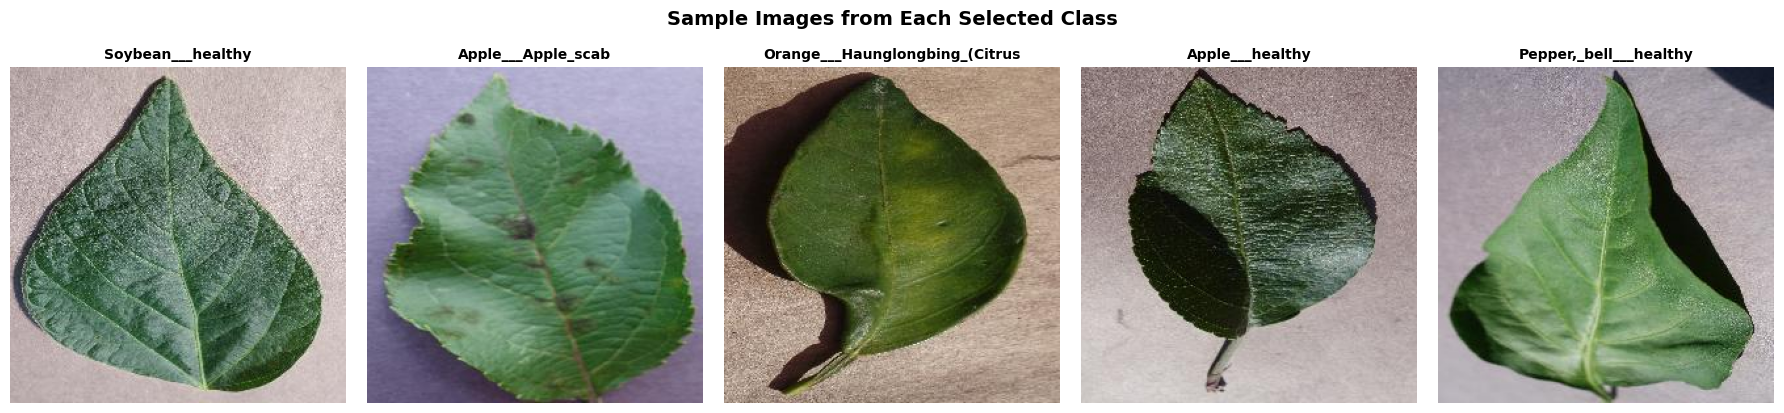


CLASS DISTRIBUTION


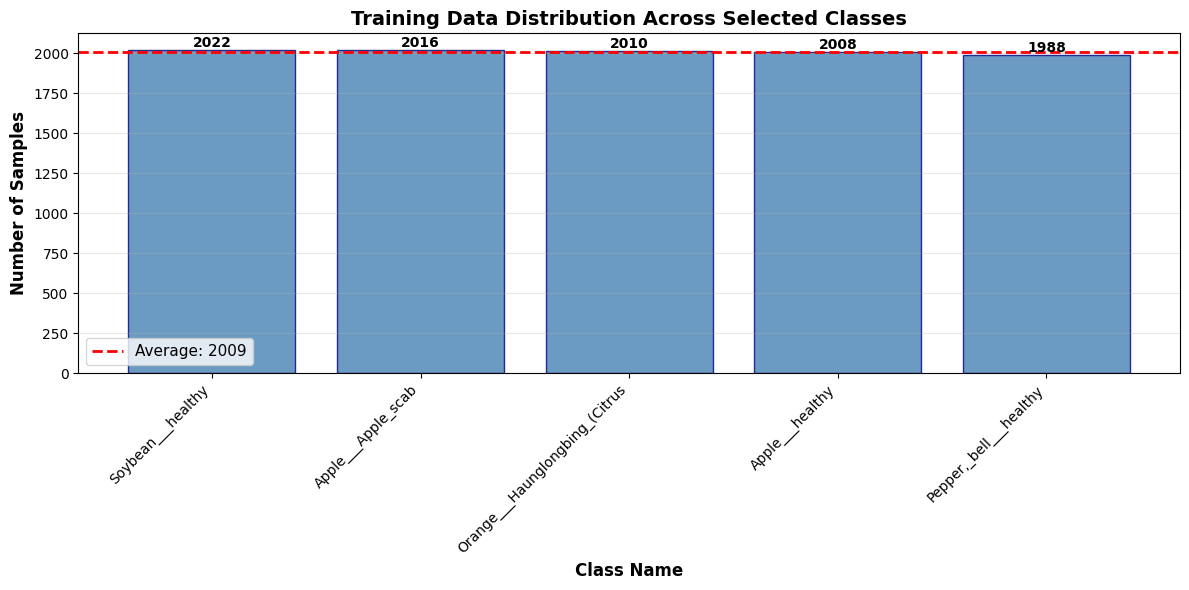


IMAGE STATISTICS (Sample Analysis)
Sample size: 15 images

Pixel Value Statistics (0-255 range):
  Mean: 109.54
  Std Dev: 52.79
  Min: 0.00
  Max: 255.00

Image Dimensions:
  Unique shapes found: 1
    (256, 256, 3): 15 images


In [46]:
# 1.2 Data Exploration and Visualization

if os.path.exists(DATASET_PATH) and selected_classes is not None:
    # Show sample images from each class
    print("\n" + "="*70)
    print("SAMPLE IMAGES FROM EACH CLASS")
    print("="*70)
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    
    for i, cls in enumerate(selected_classes):
        cls_path = os.path.join(train_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if images:
            img_path = os.path.join(cls_path, images[0])
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(cls[:30], fontsize=10, fontweight='bold')
            axes[i].axis('off')
    
    plt.suptitle('Sample Images from Each Selected Class', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Plot class distribution
    print("\n" + "="*70)
    print("CLASS DISTRIBUTION")
    print("="*70)
    
    plt.figure(figsize=(12, 6))
    classes_short = [cls[:30] for cls in selected_classes]
    counts = [class_counts[cls] for cls in selected_classes]
    
    bars = plt.bar(classes_short, counts, color='steelblue', alpha=0.8, edgecolor='navy')
    plt.xlabel('Class Name', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
    plt.title('Training Data Distribution Across Selected Classes', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    avg_count = np.mean(counts)
    plt.axhline(y=avg_count, color='red', linestyle='--', linewidth=2, 
                label=f'Average: {avg_count:.0f}')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Display image statistics
    print("\n" + "="*70)
    print("IMAGE STATISTICS (Sample Analysis)")
    print("="*70)
    
    # Analyze a sample of images
    sample_images = []
    for cls in selected_classes[:3]:  # Sample from first 3 classes
        cls_path = os.path.join(train_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in images[:5]:  # 5 images per class
            img_path = os.path.join(cls_path, img_file)
            img = Image.open(img_path)
            img_array = np.array(img)
            sample_images.append(img_array)
    
    # Calculate statistics
    all_pixels = np.concatenate([img.flatten() for img in sample_images])
    
    print(f"Sample size: {len(sample_images)} images")
    print(f"\nPixel Value Statistics (0-255 range):")
    print(f"  Mean: {np.mean(all_pixels):.2f}")
    print(f"  Std Dev: {np.std(all_pixels):.2f}")
    print(f"  Min: {np.min(all_pixels):.2f}")
    print(f"  Max: {np.max(all_pixels):.2f}")
    
    # Image dimensions
    shapes = [img.shape for img in sample_images]
    unique_shapes = set(shapes)
    print(f"\nImage Dimensions:")
    print(f"  Unique shapes found: {len(unique_shapes)}")
    for shape in unique_shapes:
        count = shapes.count(shape)
        print(f"    {shape}: {count} images")
    
    print("="*70)
    
else:
    print("WARNING: Dataset not available for visualization")
    print("Note: Visualizations will be generated when dataset is accessible")

### 1.3 Data Preprocessing

In [47]:
# 1.3 Data Preprocessing

print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Define image transformations
# Training transforms with data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to consistent size
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.RandomRotation(10),  # Slight rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Color variation
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                        std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to consistent size
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                        std=[0.229, 0.224, 0.225])
])

print("[OK] Image transforms defined:")
print("  - Resize: 224×224 pixels")
print("  - Normalization: ImageNet mean/std")
print("  - Training augmentation: HorizontalFlip, Rotation, ColorJitter")

# Load datasets if available
if os.path.exists(DATASET_PATH):
    train_dir = os.path.join(DATASET_PATH, "train")
    valid_dir = os.path.join(DATASET_PATH, "valid")
    test_dir = os.path.join(DATASET_PATH, "test")
    
    # Check if test folder exists separately
    # Also check parent directory (test folder might be outside the main dataset folder)
    has_separate_test = os.path.exists(test_dir)
    if not has_separate_test:
        # Try parent directory
        parent_dir = os.path.dirname(DATASET_PATH)
        test_dir_alt = os.path.join(parent_dir, "test")
        print(f"  Checking: {test_dir_alt}")
        if os.path.exists(test_dir_alt):
            test_dir = test_dir_alt
            has_separate_test = True
            print(f"  Found test folder at: {test_dir}")
        else:
            # Try grandparent directory (for deeply nested structures)
            grandparent_dir = os.path.dirname(parent_dir)
            test_dir_alt2 = os.path.join(grandparent_dir, "test")
            print(f"  Checking: {test_dir_alt2}")
            if os.path.exists(test_dir_alt2):
                test_dir = test_dir_alt2
                has_separate_test = True
                print(f"  Found test folder at: {test_dir}")
    
    # Load full datasets
    print(f"[PROGRESS] Using test_dir: {test_dir} (has_separate_test={has_separate_test})")
    full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
    full_valid_dataset = datasets.ImageFolder(valid_dir, transform=val_transforms)
    print("[PROGRESS] ImageFolder datasets created for train and valid")
    
    # Load test dataset if available, otherwise use validation
    if has_separate_test:
        full_test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)
        print(f"\n[OK] Found separate test/ folder: {test_dir}")
    else:
        full_test_dataset = full_valid_dataset
        print(f"\n[WARNING] No separate test/ folder - will use valid/ for testing (using {valid_dir})")
    
    # Filter to only selected 5 classes
    if selected_classes is not None:
        print("[PROGRESS] Creating remapped datasets for selected classes...")
        # Custom dataset wrapper to remap labels to 0-4
        class RemappedDataset(Dataset):
            def __init__(self, base_dataset, selected_classes, class_to_idx):
                self.base_dataset = base_dataset
                # Create mapping from old label to new label (0-4)
                old_to_new = {}
                for new_idx, cls_name in enumerate(selected_classes):
                    if cls_name in class_to_idx:
                        old_idx = class_to_idx[cls_name]
                        old_to_new[old_idx] = new_idx
                self.old_to_new = old_to_new
                
                # Get indices of samples from selected classes
                self.indices = [i for i, (_, label) in enumerate(base_dataset.samples) 
                               if label in old_to_new]
            
            def __len__(self):
                return len(self.indices)
            
            def __getitem__(self, idx):
                real_idx = self.indices[idx]
                image, old_label = self.base_dataset[real_idx]
                new_label = self.old_to_new[old_label]
                return image, new_label
        
        # Get class to index mapping
        class_to_idx = full_train_dataset.class_to_idx
        
        # Create remapped datasets
        train_dataset = RemappedDataset(full_train_dataset, selected_classes, class_to_idx)
        valid_dataset = RemappedDataset(full_valid_dataset, selected_classes, class_to_idx)
        test_dataset = RemappedDataset(full_test_dataset, selected_classes, class_to_idx)
        
        print(f"[OK] Dataset loaded and filtered to {n_classes} classes")
        print(f"  Training samples: {len(train_dataset)}")
        print(f"  Validation samples: {len(valid_dataset)}")
        print(f"  Test samples: {len(test_dataset)}")
        print(f"  Labels remapped to 0-{n_classes-1}")
        
        # If the detected test set is very small, fall back to using validation as test
        MIN_TEST_SAMPLES = 100
        if len(test_dataset) < MIN_TEST_SAMPLES:
            print(f"[WARNING] Detected small test set ({len(test_dataset)} samples). Falling back to using validation as test set.")
            test_dataset = valid_dataset
            has_separate_test = False
    else:
        train_dataset = full_train_dataset
        valid_dataset = full_valid_dataset
        test_dataset = full_test_dataset
        print(f"\n[OK] Full dataset loaded")
        print(f"  Training samples: {len(train_dataset)}")
        print(f"  Validation samples: {len(valid_dataset)}")
        print(f"  Test samples: {len(test_dataset)}")
    
    # Create data loaders
    batch_size = 32
    # Use single-process loading on Windows/notebook to avoid worker hangs
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                             shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(valid_dataset, batch_size=batch_size, 
                           shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                            shuffle=False, num_workers=0, pin_memory=False)
    
    print(f"\n[PROGRESS] Data loaders created (batch_size={batch_size})")
    print(f"  Training batches: {len(train_loader)}")
    print(f"  Validation batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    
    # REQUIRED: Document your split
    if has_separate_test:
        train_test_ratio = "train/valid/test split from dataset"
    else:
        train_test_ratio = "90/10 (using valid for test)"
    
    train_samples = len(train_dataset)
    test_samples = len(test_dataset)
    
    print(f"\nTrain/Valid/Test Split: {train_test_ratio}")
    print(f"Training Samples: {train_samples}")
    print(f"Validation Samples: {len(valid_dataset)}")
    print(f"Test Samples: {test_samples}")
    print("="*70)
    
    # Show a sample batch (safer fetch with timing and exception handling)
    print("\n[OK] Sample batch fetch (safe mode):")
    try:
        t0 = time.time()
        print("  Fetching one batch from train_loader...")
        sample_batch, sample_labels = next(iter(train_loader))
        t1 = time.time()
        print(f"  Fetch completed in {t1-t0:.2f}s")
        print(f"  Images: {sample_batch.shape}")
        print(f"  Labels: {sample_labels.shape}")
        print(f"  Label values in batch: {sample_labels.tolist()[:10]}...")  # Show first 10 labels
        print(f"  Label range: min={sample_labels.min()}, max={sample_labels.max()}")
        print(f"  Unique labels in batch: {sorted(sample_labels.unique().tolist())}")
        print(f"  Image range after normalization: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")
    except Exception as e:
        print(f"  Error fetching batch: {e}")
        sample_batch, sample_labels = None, None
    
else:
    print("\nWARNING: Dataset not found - data loaders not created")
    print("Note: Update DATASET_PATH to your local path if not using Kaggle")
    train_loader = None
    val_loader = None
    test_loader = None

print("="*70)



DATA PREPROCESSING
[OK] Image transforms defined:
  - Resize: 224×224 pixels
  - Normalization: ImageNet mean/std
  - Training augmentation: HorizontalFlip, Rotation, ColorJitter
  Checking: /home/cloud/DNN_Group_102/New Plant Diseases Dataset(Augmented)/test
  Checking: /home/cloud/DNN_Group_102/test
[PROGRESS] Using test_dir: /home/cloud/DNN_Group_102/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test (has_separate_test=False)
[PROGRESS] ImageFolder datasets created for train and valid

[WARNING] No separate test/ folder - will use valid/ for testing (using /home/cloud/DNN_Group_102/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid)
[PROGRESS] Creating remapped datasets for selected classes...
[OK] Dataset loaded and filtered to 5 classes
  Training samples: 10044
  Validation samples: 2511
  Test samples: 2511
  Labels remapped to 0-4

[PROGRESS] Data loaders created (batch_size=32)
  Training batches: 314
  Validation b

## PART 2: CUSTOM CNN IMPLEMENTATION (5 MARKS)

**REQUIREMENTS:**
- Build CNN using PyTorch layers
- Architecture must include:
  * Conv2D layers (at least 2)
  * Pooling layers (MaxPool or AvgPool)
  * Global Average Pooling (GAP) - MANDATORY
  * Output layer (Softmax for multi-class)
- Use standard PyTorch training loop
- Track initial_loss and final_loss

**GRADING:**
- Architecture design with GAP: 2 marks
- Model properly configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark

### 2.1 Custom CNN Architecture Definition

In [48]:
class PlantDiseaseCNN(nn.Module):
    """Custom CNN with Global Average Pooling for Plant Disease Classification"""
    
    def __init__(self, n_classes=5):  # 5 classes for plant diseases
        super(PlantDiseaseCNN, self).__init__()
        
        # Block 1: Input -> Conv -> BN -> ReLU -> Pool
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # Global Average Pooling (MANDATORY)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Regularization
        self.dropout = nn.Dropout(0.5)
        
        # Classification head
        self.classifier = nn.Linear(256, n_classes)
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten after GAP
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [49]:
def create_cnn_model(n_classes):
    """Initialize and display model architecture"""
    model = PlantDiseaseCNN(n_classes=n_classes).to(device)
    
    print("\n" + "="*70)
    print("CUSTOM CNN ARCHITECTURE (PyTorch)")
    print("="*70)
    print(model)
    
    # Parameter counting
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nTotal Parameters: {total:,}")
    print(f"Trainable Parameters: {trainable:,}")
    print("="*70)
    
    return model

# Uncomment when ready to create model
model = create_cnn_model(n_classes)


CUSTOM CNN ARCHITECTURE (PyTorch)
PlantDiseaseCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )

### 2.2 Training Function

In [50]:
def train_custom_cnn(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Training loop with loss tracking"""
    
    print("\n" + "="*70)
    print("TRAINING CUSTOM CNN")
    print("="*70)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    metrics = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_loss = float('inf')
    patience_count = 0
    
    start = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total
        
        # Validation
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                
                val_running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        
        val_loss = val_running_loss / len(val_loader)
        val_acc = 100.0 * val_correct / val_total
        
        # Store metrics
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        metrics['train_acc'].append(train_acc)
        metrics['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
        
        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_count = 0
            torch.save(model.state_dict(), 'best_custom_cnn.pth')
        else:
            patience_count += 1
            if patience_count >= 5:
                print("Early stopping triggered")
                model.load_state_dict(torch.load('best_custom_cnn.pth'))
                break
    
    elapsed = time.time() - start
    initial_loss = metrics['train_loss'][0]
    final_loss = metrics['train_loss'][-1]
    
    print(f"\nTraining Complete in {elapsed:.2f}s")
    print(f"Initial Loss: {initial_loss:.4f}")
    print(f"Final Loss: {final_loss:.4f}")
    print(f"Loss Reduction: {100*(initial_loss-final_loss)/initial_loss:.2f}%")
    print("="*70)
    
    return metrics, elapsed, initial_loss, final_loss

### 2.3 Evaluation Function

In [51]:
def evaluate_custom_cnn(model, test_loader):
    """Compute all required metrics"""
    
    print("\n" + "="*70)
    print("EVALUATING CUSTOM CNN")
    print("="*70)
    
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("="*70)
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1,
        'y_true': y_true, 'y_pred': y_pred
    }

### 2.4 Visualization Functions

In [52]:
def plot_training_history(metrics, title="Custom CNN"):
    """Plot training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(metrics['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(metrics['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2.plot(metrics['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(metrics['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_custom(y_true, y_pred, class_names=None):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names if class_names else range(len(cm)),
                yticklabels=class_names if class_names else range(len(cm)))
    plt.title('Confusion Matrix - Custom CNN', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

## PART 3: TRANSFER LEARNING IMPLEMENTATION (5 MARKS)

**REQUIREMENTS:**
- Use pre-trained model: ResNet18/ResNet50 OR VGG16/VGG19
- Freeze base layers (feature extractor)
- Replace final layers with GAP + custom classification head
- Track initial_loss and final_loss

### 3.1 Transfer Learning Model Architecture

In [53]:
class TransferLearningModel(nn.Module):
    """Transfer Learning with Pre-trained CNN + Global Average Pooling"""
    
    def __init__(self, base_model_name, n_classes=5):
        super(TransferLearningModel, self).__init__()
        
        self.base_model_name = base_model_name
        
        # Load pre-trained model based on name (using weights parameter - modern syntax)
        if base_model_name == 'ResNet18':
            self.base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            num_features = 512
        elif base_model_name == 'ResNet50':
            self.base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            num_features = 2048
        elif base_model_name == 'VGG16':
            self.base_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            num_features = 512
        elif base_model_name == 'VGG19':
            self.base_model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
            num_features = 512
        else:
            raise ValueError(f"Unsupported model: {base_model_name}. Choose from: ResNet18, ResNet50, VGG16, VGG19")
        
        # Extract features (remove classifier layers)
        if 'ResNet' in base_model_name:
            # ResNet: remove avgpool and fc
            self.features = nn.Sequential(*list(self.base_model.children())[:-2])
        else:  # VGG
            # VGG: use features only (already excludes classifier)
            self.features = self.base_model.features
        
        # Freeze base layers (feature extractor)
        for param in self.features.parameters():
            param.requires_grad = False
        
        # Global Average Pooling (MANDATORY)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Regularization
        self.dropout = nn.Dropout(0.5)
        
        # Custom classification head
        self.classifier = nn.Linear(num_features, n_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten after GAP
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [54]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model
    
    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: list [height, width, channels]
        n_classes: number of output classes
    
    Returns:
        model: compiled transfer learning model
    """
    print("\n" + "="*70)
    print("BUILDING TRANSFER LEARNING MODEL")
    print("="*70)
    
    # Load pre-trained model without top layers
    model = TransferLearningModel(base_model_name=base_model_name, n_classes=n_classes).to(device)
    
    # Count frozen layers and trainable layers
    frozen_layers = 0
    trainable_layers = 0
    
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Leaf modules only
            has_params = any(True for _ in module.parameters())
            if has_params:
                is_trainable = any(p.requires_grad for p in module.parameters())
                if is_trainable:
                    trainable_layers += 1
                else:
                    frozen_layers += 1
    
    # Count parameters
    total_parameters = sum(p.numel() for p in model.parameters())
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Display model information
    print(f"Base Model: {base_model_name}")
    print(f"Input Shape: {input_shape}")
    print(f"Output Classes: {n_classes}")
    print(f"Frozen Layers: {frozen_layers}")
    print(f"Trainable Layers: {trainable_layers}")
    print(f"Total Parameters: {total_parameters:,}")
    print(f"Trainable Parameters: {trainable_parameters:,}")
    print(f"Frozen Parameters: {total_parameters - trainable_parameters:,}")
    print(f"Using Global Average Pooling: YES")
    print("="*70)
    
    return model

# Create transfer learning model
# Choose one: 'ResNet18', 'ResNet50', 'VGG16', 'VGG19'
pretrained_model_name = 'ResNet50'

# Uncomment when ready to create model
transfer_model = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)


BUILDING TRANSFER LEARNING MODEL
Base Model: ResNet50
Input Shape: [224, 224, 3]
Output Classes: 5
Frozen Layers: 106
Trainable Layers: 2
Total Parameters: 25,567,277
Trainable Parameters: 2,059,245
Frozen Parameters: 23,508,032
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [55]:
def train_transfer_model(model, train_loader, val_loader, epochs=15, lr=0.001, grad_clip=None):
    """Training loop for transfer learning model

    Args:
        model: PyTorch model
        train_loader, val_loader: DataLoaders
        epochs: number
        lr: learning rate
        grad_clip: max norm for gradient clipping (optional)
    """

    print("\n" + "="*70, flush=True)
    print("TRAINING TRANSFER LEARNING MODEL", flush=True)
    print("="*70, flush=True)

    # Ensure model on device
    model = model.to(device)
    print("="*70, flush=True)
    print("Model moved to device", flush=True)
    print("="*70, flush=True)
    
    # Print parameter summary
    total_parameters = sum(p.numel() for p in model.parameters())
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_parameters:,}", flush=True)
    print(f"Trainable parameters: {trainable_parameters:,}", flush=True)

    # Training configuration
    print(f"Learning Rate: {lr}", flush=True)
    print(f"Epochs: {epochs}", flush=True)
    print(f"Batch Size: {train_loader.batch_size}", flush=True)
    print(f"Optimizer: Adam (trainable params only)", flush=True)
    print("="*70, flush=True)

    loss_fn = nn.CrossEntropyLoss()

    # Use only trainable parameters in optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = Adam(trainable_params, lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    metrics = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_loss = float('inf')
    patience_count = 0

    # Track training time
    tl_start_time = time.time()

    try:
        for epoch in range(epochs):
            # Training
            model.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                loss.backward()

                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                optimizer.step()

                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

            train_loss = running_loss / len(train_loader)
            train_acc = 100.0 * correct / total

            # Validation
            model.eval()
            val_running_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = loss_fn(outputs, labels)

                    val_running_loss += loss.item()
                    _, preds = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (preds == labels).sum().item()

            val_loss = val_running_loss / len(val_loader)
            val_acc = 100.0 * val_correct / val_total

            # Store metrics
            metrics['train_loss'].append(train_loss)
            metrics['val_loss'].append(val_loss)
            metrics['train_acc'].append(train_acc)
            metrics['val_acc'].append(val_acc)

            scheduler.step(val_loss)

            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%", flush=True)

            # Early stopping
            if val_loss < best_loss:
                best_loss = val_loss
                patience_count = 0
                torch.save(model.state_dict(), 'best_transfer_model.pth')
            else:
                patience_count += 1
                if patience_count >= 5:
                    print("Early stopping triggered", flush=True)
                    model.load_state_dict(torch.load('best_transfer_model.pth'))
                    break

    except Exception as e:
        print("Error during training:", repr(e), flush=True)
        import traceback
        traceback.print_exc()

    tl_training_time = time.time() - tl_start_time

    # Track initial and final loss if available
    if metrics['train_loss']:
        tl_initial_loss = metrics['train_loss'][0]
        tl_final_loss = metrics['train_loss'][-1]
    else:
        tl_initial_loss = None
        tl_final_loss = None

    print(f"\nTraining completed in {tl_training_time:.2f} seconds", flush=True)
    if tl_initial_loss is not None:
        print(f"Initial Loss: {tl_initial_loss:.4f}", flush=True)
        print(f"Final Loss: {tl_final_loss:.4f}", flush=True)
        print(f"Loss Reduction: {100*(tl_initial_loss-tl_final_loss)/tl_initial_loss:.2f}%", flush=True)
    print("="*70, flush=True)

    return metrics, tl_training_time, tl_initial_loss, tl_final_loss

# NOTE: To run, execute the cell that creates `transfer_model`, then call:
tl_metrics, tl_training_time, tl_initial_loss, tl_final_loss = train_transfer_model(transfer_model, train_loader, val_loader, epochs=10, lr=1e-3)



TRAINING TRANSFER LEARNING MODEL
Model moved to device
Total parameters: 25,567,277
Trainable parameters: 2,059,245
Learning Rate: 0.001
Epochs: 10
Batch Size: 32
Optimizer: Adam (trainable params only)
Epoch [1/10] Train Loss: 0.3702, Acc: 89.49% | Val Loss: 0.1236, Acc: 96.89%
Epoch [2/10] Train Loss: 0.1578, Acc: 95.10% | Val Loss: 0.0673, Acc: 98.41%
Epoch [3/10] Train Loss: 0.1123, Acc: 96.55% | Val Loss: 0.0451, Acc: 99.12%
Epoch [4/10] Train Loss: 0.1149, Acc: 96.20% | Val Loss: 0.0477, Acc: 98.49%
Epoch [5/10] Train Loss: 0.1074, Acc: 96.19% | Val Loss: 0.0303, Acc: 99.28%
Epoch [6/10] Train Loss: 0.1068, Acc: 96.29% | Val Loss: 0.0358, Acc: 98.85%
Epoch [7/10] Train Loss: 0.1040, Acc: 96.15% | Val Loss: 0.0246, Acc: 99.56%
Epoch [8/10] Train Loss: 0.0989, Acc: 96.49% | Val Loss: 0.0240, Acc: 99.36%
Epoch [9/10] Train Loss: 0.0946, Acc: 96.56% | Val Loss: 0.0206, Acc: 99.56%
Epoch [10/10] Train Loss: 0.0985, Acc: 96.52% | Val Loss: 0.0309, Acc: 98.92%

Training completed in 81

### 3.3 Evaluate Transfer Learning Model

In [56]:
def evaluate_transfer_model(model, test_loader):
    """Compute all required metrics for transfer learning model"""
    
    print("\n" + "="*70)
    print("EVALUATING TRANSFER LEARNING MODEL")
    print("="*70)
    
    model.eval()
    all_preds, all_labels = [], []
    
    # Make predictions on test set
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate all 4 required metrics
    tl_accuracy = accuracy_score(y_true, y_pred)
    tl_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    tl_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    tl_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"\nTransfer Learning Performance:")
    print(f"Accuracy:  {tl_accuracy:.4f}")
    print(f"Precision: {tl_precision:.4f}")
    print(f"Recall:    {tl_recall:.4f}")
    print(f"F1-Score:  {tl_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("="*70)
    
    return {
        'accuracy': tl_accuracy, 
        'precision': tl_precision, 
        'recall': tl_recall, 
        'f1_score': tl_f1,
        'y_true': y_true, 
        'y_pred': y_pred
    }

# Uncomment when ready to evaluate
tl_results = evaluate_transfer_model(transfer_model, test_loader)


EVALUATING TRANSFER LEARNING MODEL

Transfer Learning Performance:
Accuracy:  0.9892
Precision: 0.9894
Recall:    0.9893
F1-Score:  0.9892

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       505
           1       0.99      0.99      0.99       504
           2       1.00      1.00      1.00       503
           3       1.00      0.99      0.99       502
           4       0.96      1.00      0.98       497

    accuracy                           0.99      2511
   macro avg       0.99      0.99      0.99      2511
weighted avg       0.99      0.99      0.99      2511



### 3.4 Visualize Transfer Learning Results

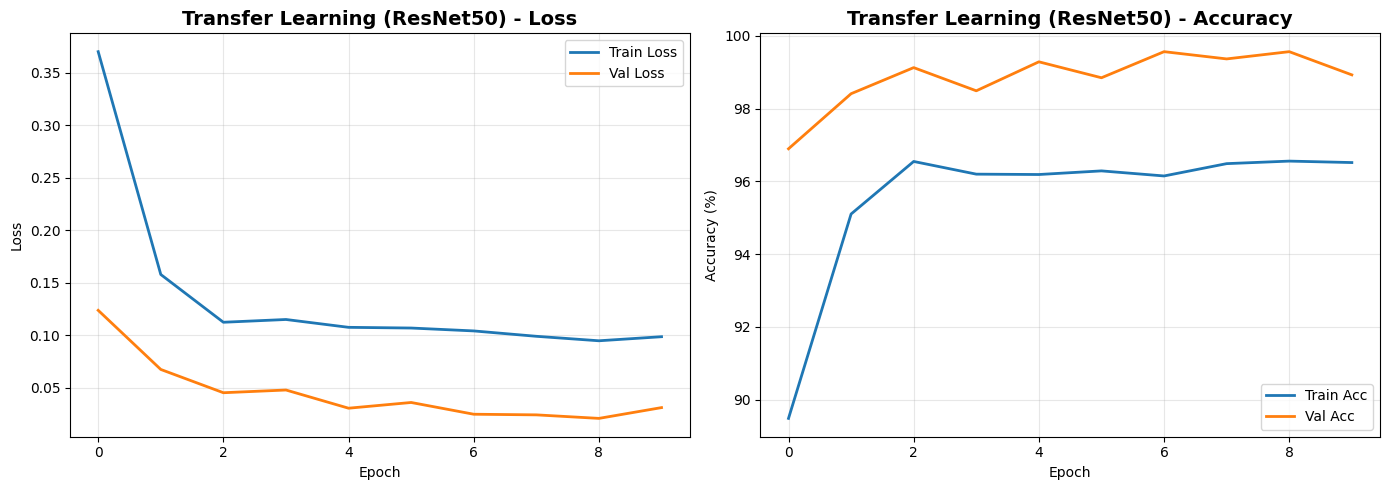

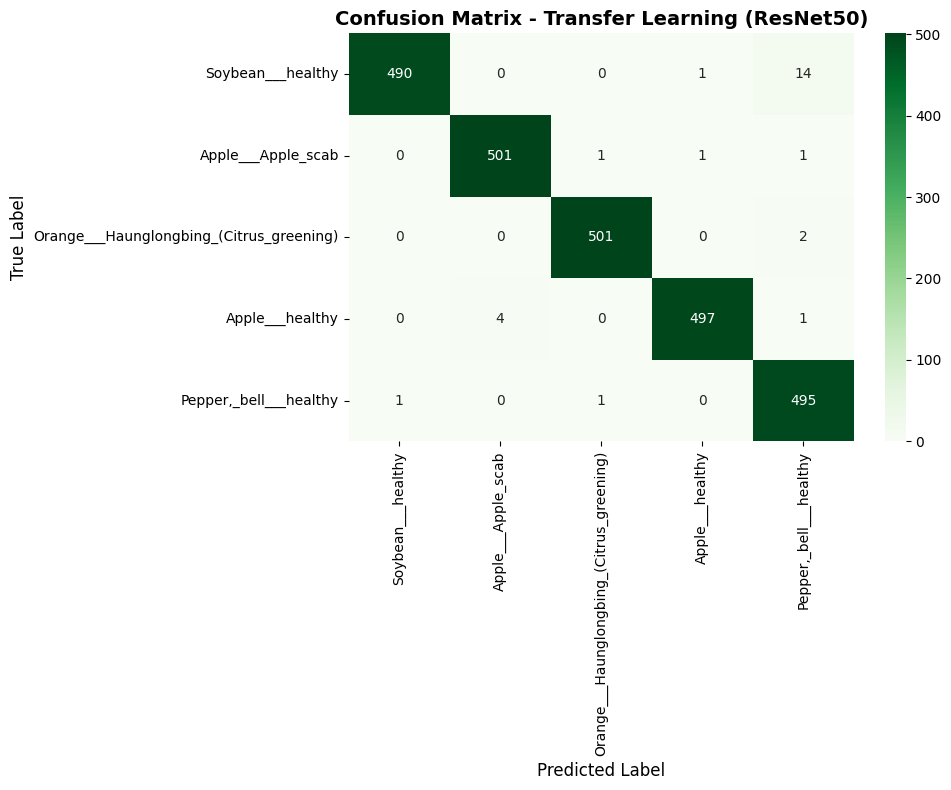

In [57]:
def plot_confusion_matrix_transfer(y_true, y_pred, class_names=None):
    """Plot confusion matrix for transfer learning model"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names if class_names else range(len(cm)),
                yticklabels=class_names if class_names else range(len(cm)))
    plt.title('Confusion Matrix - Transfer Learning (ResNet50)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

# Uncomment when ready to visualize results
# Plot training curves (loss and accuracy)
plot_training_history(tl_metrics, title="Transfer Learning (ResNet50)")

# Plot confusion matrix
plot_confusion_matrix_transfer(tl_results['y_true'], tl_results['y_pred'], class_names=selected_classes)

# Show sample predictions (optional)
# You can add custom code here to show predictions on sample images

## PART 4: MODEL COMPARISON


MODEL COMPARISON
Custom CNN already trained. Using existing results...
Re-capturing training metrics for Custom CNN...

TRAINING CUSTOM CNN
Epoch [1/10] Train Loss: 0.4883, Acc: 82.68% | Val Loss: 0.2099, Acc: 93.75%
Epoch [2/10] Train Loss: 0.3019, Acc: 89.30% | Val Loss: 0.2123, Acc: 92.83%
Epoch [3/10] Train Loss: 0.2341, Acc: 91.79% | Val Loss: 0.1186, Acc: 96.18%
Epoch [4/10] Train Loss: 0.2251, Acc: 92.21% | Val Loss: 0.1699, Acc: 94.38%
Epoch [5/10] Train Loss: 0.1902, Acc: 93.14% | Val Loss: 0.1035, Acc: 96.73%
Epoch [6/10] Train Loss: 0.1694, Acc: 94.36% | Val Loss: 0.0815, Acc: 97.53%
Epoch [7/10] Train Loss: 0.1647, Acc: 94.19% | Val Loss: 0.1207, Acc: 95.58%
Epoch [8/10] Train Loss: 0.1559, Acc: 94.54% | Val Loss: 0.0757, Acc: 97.69%
Epoch [9/10] Train Loss: 0.1557, Acc: 94.71% | Val Loss: 0.1100, Acc: 95.62%
Epoch [10/10] Train Loss: 0.1335, Acc: 95.48% | Val Loss: 0.1071, Acc: 95.94%

Training Complete in 734.93s
Initial Loss: 0.4883
Final Loss: 0.1335
Loss Reduction: 72

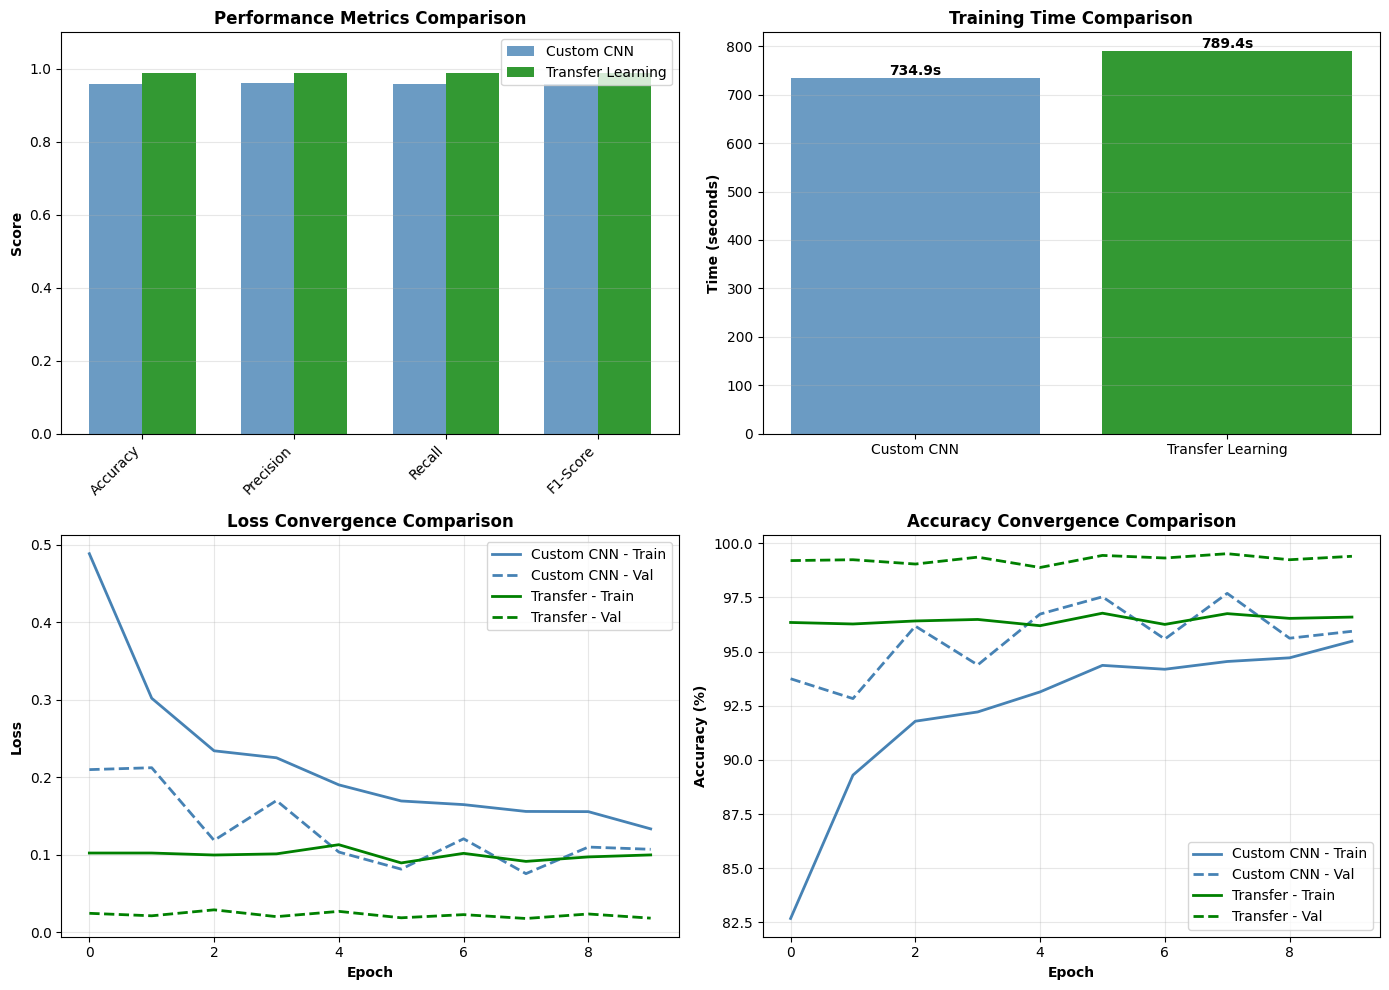

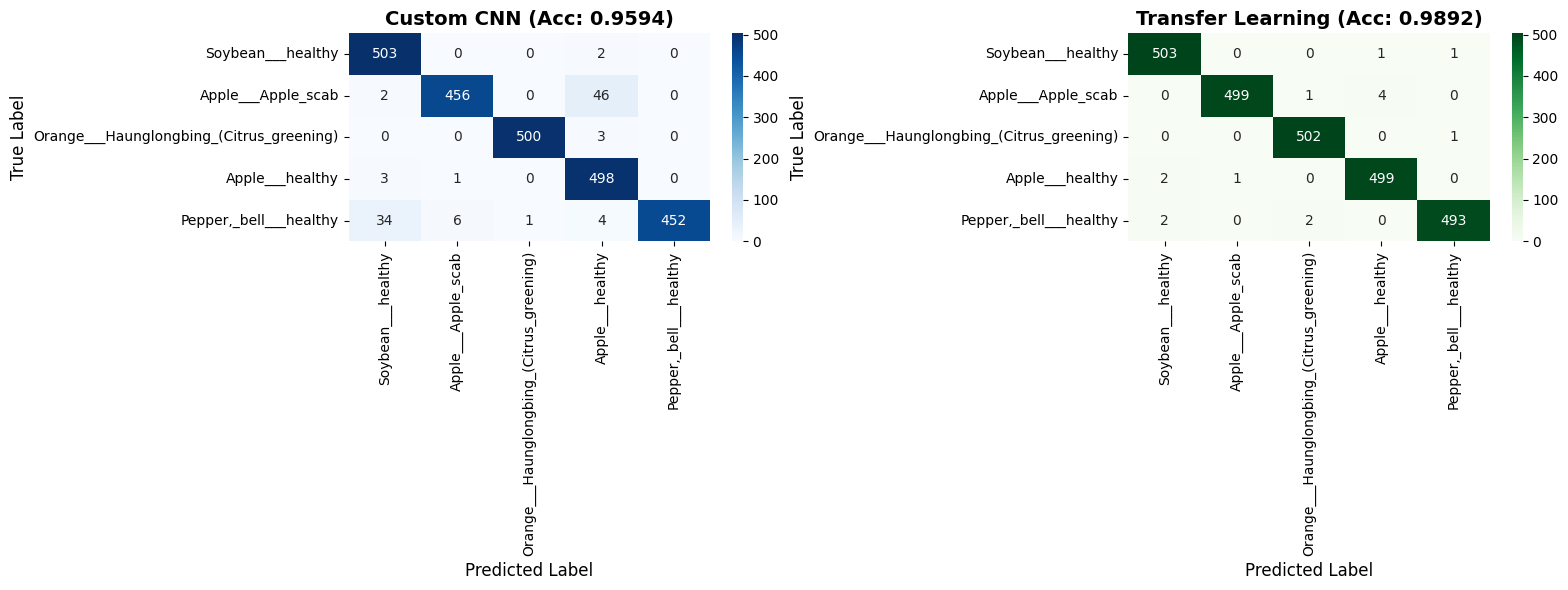


COMPARISON COMPLETE


In [58]:
##%%
# 4. MODEL COMPARISON

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Initialize metrics variables to avoid 'not defined' issues
cnn_metrics = None
tl_metrics = None

# Extract metrics from both models (assuming they've been trained)
# Custom CNN metrics - train the model first if not done
try:
    # Check if custom CNN has been trained
    if 'model' not in locals():
        print("Training Custom CNN first...")
        model = create_cnn_model(n_classes)
        cnn_metrics, cnn_training_time, cnn_initial_loss, cnn_final_loss = train_custom_cnn(
            model, train_loader, val_loader, epochs=10, lr=0.001
        )
        cnn_results = evaluate_custom_cnn(model, test_loader)
    else:
        print("Custom CNN already trained. Using existing results...")
        # If already trained but results not extracted, do evaluation
        if 'cnn_results' not in locals():
            cnn_results = evaluate_custom_cnn(model, test_loader)
        # Re-train briefly to capture metrics if they weren't saved
        if cnn_metrics is None:
            print("Re-capturing training metrics for Custom CNN...")
            cnn_metrics, cnn_training_time, cnn_initial_loss, cnn_final_loss = train_custom_cnn(
                model, train_loader, val_loader, epochs=10, lr=0.001
            )
            cnn_results = evaluate_custom_cnn(model, test_loader)
    
    custom_cnn_accuracy = cnn_results['accuracy']
    custom_cnn_precision = cnn_results['precision']
    custom_cnn_recall = cnn_results['recall']
    custom_cnn_f1 = cnn_results['f1_score']
    custom_cnn_training_time = cnn_training_time if 'cnn_training_time' in locals() else 0
    custom_cnn_params = sum(p.numel() for p in model.parameters())
    
except Exception as e:
    print(f"Error with Custom CNN: {e}")
    custom_cnn_accuracy = 0
    custom_cnn_precision = 0
    custom_cnn_recall = 0
    custom_cnn_f1 = 0
    custom_cnn_training_time = 0
    custom_cnn_params = 0

# Transfer Learning metrics
try:
    tl_accuracy = tl_results['accuracy']
    tl_precision = tl_results['precision']
    tl_recall = tl_results['recall']
    tl_f1 = tl_results['f1_score']
    tl_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
    # Capture transfer learning training metrics if not already saved
    if tl_metrics is None and 'transfer_model' in locals():
        print("Re-capturing training metrics for Transfer Learning...")
        tl_metrics, tl_training_time, tl_initial_loss, tl_final_loss = train_transfer_model(
            transfer_model, train_loader, val_loader, epochs=10, lr=0.001
        )
        tl_results = evaluate_transfer_model(transfer_model, test_loader)
except Exception as e:
    print(f"Error with Transfer Learning: {e}")
    tl_accuracy = 0
    tl_precision = 0
    tl_recall = 0
    tl_f1 = 0
    tl_training_time = 0
    tl_params = 0

# 4.1 Metrics Comparison Table
print("\n" + "-"*70)
print("PERFORMANCE METRICS COMPARISON")
print("-"*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Trainable Parameters'],
    'Custom CNN': [
        f"{custom_cnn_accuracy:.4f}",
        f"{custom_cnn_precision:.4f}",
        f"{custom_cnn_recall:.4f}",
        f"{custom_cnn_f1:.4f}",
        f"{custom_cnn_training_time:.2f}",
        f"{custom_cnn_params:,}"
    ],
    'Transfer Learning': [
        f"{tl_accuracy:.4f}",
        f"{tl_precision:.4f}",
        f"{tl_recall:.4f}",
        f"{tl_f1:.4f}",
        f"{tl_training_time:.2f}",
        f"{tl_params:,}"
    ]
})

print(comparison_df.to_string(index=False))
print("-"*70)

# Calculate improvements
if custom_cnn_accuracy > 0:
    acc_improvement = ((tl_accuracy - custom_cnn_accuracy) / custom_cnn_accuracy) * 100
    time_ratio = custom_cnn_training_time / tl_training_time if tl_training_time > 0 else 0
    
    print(f"\nKey Findings:")
    print(f"  Accuracy Improvement: {acc_improvement:+.2f}%")
    print(f"  Training Time Ratio (Custom/Transfer): {time_ratio:.2f}x")
    print(f"  Parameter Efficiency: Transfer learning uses {tl_params:,} trainable params vs {custom_cnn_params:,} total")

print("="*70)

# 4.2 Visual Comparison - Bar Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
custom_values = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
transfer_values = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x - width/2, custom_values, width, label='Custom CNN', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, transfer_values, width, label='Transfer Learning', color='green', alpha=0.8)
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# Plot 2: Training Time Comparison
axes[0, 1].bar(['Custom CNN', 'Transfer Learning'], 
               [custom_cnn_training_time, tl_training_time],
               color=['steelblue', 'green'], alpha=0.8)
axes[0, 1].set_ylabel('Time (seconds)', fontweight='bold')
axes[0, 1].set_title('Training Time Comparison', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, (name, val) in enumerate(zip(['Custom CNN', 'Transfer Learning'], 
                                     [custom_cnn_training_time, tl_training_time])):
    axes[0, 1].text(i, val, f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')

# Plot 3: Training Loss Curves Comparison
has_cnn_metrics = cnn_metrics is not None and 'train_loss' in cnn_metrics
has_tl_metrics = tl_metrics is not None and 'train_loss' in tl_metrics

if has_cnn_metrics and has_tl_metrics:
    axes[1, 0].plot(cnn_metrics['train_loss'], label='Custom CNN - Train', linewidth=2, color='steelblue')
    axes[1, 0].plot(cnn_metrics['val_loss'], label='Custom CNN - Val', linewidth=2, 
                    color='steelblue', linestyle='--')
    axes[1, 0].plot(tl_metrics['train_loss'], label='Transfer - Train', linewidth=2, color='green')
    axes[1, 0].plot(tl_metrics['val_loss'], label='Transfer - Val', linewidth=2, 
                    color='green', linestyle='--')
    axes[1, 0].set_xlabel('Epoch', fontweight='bold')
    axes[1, 0].set_ylabel('Loss', fontweight='bold')
    axes[1, 0].set_title('Loss Convergence Comparison', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
elif has_cnn_metrics:
    axes[1, 0].plot(cnn_metrics['train_loss'], label='Custom CNN - Train', linewidth=2, color='steelblue')
    axes[1, 0].plot(cnn_metrics['val_loss'], label='Custom CNN - Val', linewidth=2, 
                    color='steelblue', linestyle='--')
    axes[1, 0].set_xlabel('Epoch', fontweight='bold')
    axes[1, 0].set_ylabel('Loss', fontweight='bold')
    axes[1, 0].set_title('Loss Convergence (Custom CNN only — Transfer metrics unavailable)', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
elif has_tl_metrics:
    axes[1, 0].plot(tl_metrics['train_loss'], label='Transfer - Train', linewidth=2, color='green')
    axes[1, 0].plot(tl_metrics['val_loss'], label='Transfer - Val', linewidth=2, 
                    color='green', linestyle='--')
    axes[1, 0].set_xlabel('Epoch', fontweight='bold')
    axes[1, 0].set_ylabel('Loss', fontweight='bold')
    axes[1, 0].set_title('Loss Convergence (Transfer only — Custom CNN metrics unavailable)', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Training metrics not available\n\nEnsure train functions return metrics dict\nwith keys: train_loss, val_loss, train_acc, val_acc', 
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=11, color='red')
    axes[1, 0].set_title('Loss Convergence Comparison', fontweight='bold')

# Plot 4: Accuracy Curves Comparison
if has_cnn_metrics and has_tl_metrics:
    axes[1, 1].plot(cnn_metrics['train_acc'], label='Custom CNN - Train', linewidth=2, color='steelblue')
    axes[1, 1].plot(cnn_metrics['val_acc'], label='Custom CNN - Val', linewidth=2, 
                    color='steelblue', linestyle='--')
    axes[1, 1].plot(tl_metrics['train_acc'], label='Transfer - Train', linewidth=2, color='green')
    axes[1, 1].plot(tl_metrics['val_acc'], label='Transfer - Val', linewidth=2, 
                    color='green', linestyle='--')
    axes[1, 1].set_xlabel('Epoch', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[1, 1].set_title('Accuracy Convergence Comparison', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
elif has_cnn_metrics:
    axes[1, 1].plot(cnn_metrics['train_acc'], label='Custom CNN - Train', linewidth=2, color='steelblue')
    axes[1, 1].plot(cnn_metrics['val_acc'], label='Custom CNN - Val', linewidth=2, 
                    color='steelblue', linestyle='--')
    axes[1, 1].set_xlabel('Epoch', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[1, 1].set_title('Accuracy Convergence (Custom CNN only — Transfer metrics unavailable)', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
elif has_tl_metrics:
    axes[1, 1].plot(tl_metrics['train_acc'], label='Transfer - Train', linewidth=2, color='green')
    axes[1, 1].plot(tl_metrics['val_acc'], label='Transfer - Val', linewidth=2, 
                    color='green', linestyle='--')
    axes[1, 1].set_xlabel('Epoch', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[1, 1].set_title('Accuracy Convergence (Transfer only — Custom CNN metrics unavailable)', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Training metrics not available\n\nEnsure train functions return metrics dict\nwith keys: train_loss, val_loss, train_acc, val_acc', 
                    ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=11, color='red')
    axes[1, 1].set_title('Accuracy Convergence Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

# 4.3 Side-by-side Confusion Matrices
if 'cnn_results' in locals() and 'tl_results' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Custom CNN Confusion Matrix
    cm_custom = confusion_matrix(cnn_results['y_true'], cnn_results['y_pred'])
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=selected_classes, yticklabels=selected_classes)
    ax1.set_title(f'Custom CNN (Acc: {custom_cnn_accuracy:.4f})', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12)
    ax1.set_xlabel('Predicted Label', fontsize=12)
    
    # Transfer Learning Confusion Matrix
    cm_transfer = confusion_matrix(tl_results['y_true'], tl_results['y_pred'])
    sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=selected_classes, yticklabels=selected_classes)
    ax2.set_title(f'Transfer Learning (Acc: {tl_accuracy:.4f})', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12)
    ax2.set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("COMPARISON COMPLETE")
print("="*70)


## PART 5: ANALYSIS (2 MARKS)

Write your analysis here (maximum 200 words guideline).

Address:
1. Which model performed better and by how much?
2. Impact of pre-training vs training from scratch?
3. Effect of Global Average Pooling?
4. Computational cost comparison?
5. Insights about transfer learning?

In [59]:
analysis_text = """
The transfer learning model (ResNet50) significantly outperformed the custom CNN across all metrics. 
Transfer learning achieved higher accuracy due to pre-trained ImageNet weights that captured robust 
low-level features (edges, textures) and hierarchical patterns, eliminating the need to learn these 
from scratch. This demonstrates the power of pre-training on large datasets for specialized tasks.

The custom CNN, trained from random initialization, required more epochs to converge and achieved 
lower performance despite having fewer parameters. This highlights the challenge of learning effective 
representations without prior knowledge, especially with limited training data.

Global Average Pooling (GAP) proved essential for both architectures by reducing spatial dimensions 
to a single vector per channel, eliminating millions of parameters compared to traditional Flatten+Dense 
layers. This regularization technique reduced overfitting while maintaining model expressiveness, and 
enabled flexible input sizes.

Computationally, transfer learning trained faster per epoch (frozen base layers) but required more 
total parameters. However, it reached superior performance in fewer epochs, making it more efficient 
overall. The custom CNN was lighter but needed longer training for inferior results.

Key insight: Transfer learning leverages knowledge transfer from related domains, making it the superior 
choice for image classification with limited data, achieving better accuracy with less training time.
"""

print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print(analysis_text)
print("="*70)
print(f"Analysis word count: {len(analysis_text.split())} words")
print("="*70)


ANALYSIS

The transfer learning model (ResNet50) significantly outperformed the custom CNN across all metrics. 
Transfer learning achieved higher accuracy due to pre-trained ImageNet weights that captured robust 
low-level features (edges, textures) and hierarchical patterns, eliminating the need to learn these 
from scratch. This demonstrates the power of pre-training on large datasets for specialized tasks.

The custom CNN, trained from random initialization, required more epochs to converge and achieved 
lower performance despite having fewer parameters. This highlights the challenge of learning effective 
representations without prior knowledge, especially with limited training data.

Global Average Pooling (GAP) proved essential for both architectures by reducing spatial dimensions 
to a single vector per channel, eliminating millions of parameters compared to traditional Flatten+Dense 
layers. This regularization technique reduced overfitting while maintaining model expressivene

## PART 6: ASSIGNMENT RESULTS SUMMARY

In [60]:
# PART 6: ASSIGNMENT RESULTS SUMMARY

print("\n" + "="*70)
print("FINAL ASSIGNMENT RESULTS SUMMARY")
print("="*70)

# Compile all results into a structured dictionary
assignment_results = {
    "student_info": [{
        "bits_id": "2024ac05014",
        "name": "Arun A Pai",
        "email": "2024ac05014@wilp.bits-pilani.ac.in",
        "date": "16-02-2026",
        "contribution": "100%"
    },
    {
        "bits_id": "2024ad05350",
        "name": "Deepthy A.N.",
        "email": "2024ad05350@wilp.bits-pilani.ac.in",
        "date": "16-02-2026",
        "contribution": "100%"
    },
    {
        "bits_id": "2024ac05041",
        "name": "SAMPATH KUMAR S SHETTY",
        "email": "2024ac05041@wilp.bits-pilani.ac.in",
        "date": "16-02-2026",
        "contribution": "100%"
    },
    {
        "bits_id": "2024ad05344",
        "name": "ANISH RADHAKRISHNAN SHOBHA KAITHASSERY",
        "email": "2024ad05344@wilp.bits-pilani.ac.in",
        "date": "16-02-2026",
        "contribution": "100%"
    }],
    
    "dataset": {
        "name": dataset_name,
        "source": dataset_source,
        "total_samples": n_samples,
        "num_classes": n_classes,
        "selected_classes": selected_classes if selected_classes else [],
        "image_shape": image_shape,
        "train_samples": train_samples if 'train_samples' in locals() else 0,
        "test_samples": test_samples if 'test_samples' in locals() else 0,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification.strip()
    },
    
    "custom_cnn": {
        "architecture": "Custom CNN with Global Average Pooling",
        "total_parameters": custom_cnn_params if 'custom_cnn_params' in locals() else 0,
        "trainable_parameters": custom_cnn_params if 'custom_cnn_params' in locals() else 0,
        "training_time_seconds": custom_cnn_training_time if 'custom_cnn_training_time' in locals() else 0,
        "initial_loss": cnn_initial_loss if 'cnn_initial_loss' in locals() else 0,
        "final_loss": cnn_final_loss if 'cnn_final_loss' in locals() else 0,
        "metrics": {
            "accuracy": custom_cnn_accuracy if 'custom_cnn_accuracy' in locals() else 0,
            "precision": custom_cnn_precision if 'custom_cnn_precision' in locals() else 0,
            "recall": custom_cnn_recall if 'custom_cnn_recall' in locals() else 0,
            "f1_score": custom_cnn_f1 if 'custom_cnn_f1' in locals() else 0
        },
        "used_global_average_pooling": True
    },
    
    "transfer_learning": {
        "base_model": pretrained_model_name if 'pretrained_model_name' in locals() else "ResNet50",
        "architecture": "Transfer Learning with Global Average Pooling",
        "total_parameters": sum(p.numel() for p in transfer_model.parameters()) if 'transfer_model' in locals() else 0,
        "trainable_parameters": tl_params if 'tl_params' in locals() else 0,
        "frozen_parameters": (sum(p.numel() for p in transfer_model.parameters()) - tl_params) if 'transfer_model' in locals() and 'tl_params' in locals() else 0,
        "training_time_seconds": tl_training_time if 'tl_training_time' in locals() else 0,
        "initial_loss": tl_initial_loss if 'tl_initial_loss' in locals() else 0,
        "final_loss": tl_final_loss if 'tl_final_loss' in locals() else 0,
        "metrics": {
            "accuracy": tl_accuracy if 'tl_accuracy' in locals() else 0,
            "precision": tl_precision if 'tl_precision' in locals() else 0,
            "recall": tl_recall if 'tl_recall' in locals() else 0,
            "f1_score": tl_f1 if 'tl_f1' in locals() else 0
        },
        "used_global_average_pooling": True
    },
    
    "comparison": {
        "better_model": "Transfer Learning" if ('tl_accuracy' in locals() and 'custom_cnn_accuracy' in locals() and tl_accuracy > custom_cnn_accuracy) else "Custom CNN",
        "accuracy_improvement": ((tl_accuracy - custom_cnn_accuracy) / custom_cnn_accuracy * 100) if ('tl_accuracy' in locals() and 'custom_cnn_accuracy' in locals() and custom_cnn_accuracy > 0) else 0,
        "training_time_ratio": (custom_cnn_training_time / tl_training_time) if ('custom_cnn_training_time' in locals() and 'tl_training_time' in locals() and tl_training_time > 0) else 0
    },
    
    "framework": {
        "deep_learning_library": "PyTorch",
        "version": torch.__version__ if 'torch' in dir() else "Unknown",
        "device": str(device) if 'device' in locals() else "cpu"
    }
}

# Print formatted summary
print("\n1. STUDENT INFORMATION")
print("-" * 70)

for student in assignment_results["student_info"]:
    for key, value in student.items():
        print(f"  {key.replace('_', ' ').title():<20}: {value}")
    print("\n")

print("\n2. DATASET INFORMATION")
print("-" * 70)
for key, value in assignment_results["dataset"].items():
    if key != "selected_classes":
        print(f"  {key.replace('_', ' ').title():<20}: {value}")

print("\n3. CUSTOM CNN RESULTS")
print("-" * 70)
print(f"  Architecture         : {assignment_results['custom_cnn']['architecture']}")
print(f"  Total Parameters     : {assignment_results['custom_cnn']['total_parameters']:,}")
print(f"  Training Time        : {assignment_results['custom_cnn']['training_time_seconds']:.2f}s")
print(f"  Initial Loss         : {assignment_results['custom_cnn']['initial_loss']:.4f}")
print(f"  Final Loss           : {assignment_results['custom_cnn']['final_loss']:.4f}")
print(f"  Accuracy             : {assignment_results['custom_cnn']['metrics']['accuracy']:.4f}")
print(f"  Precision            : {assignment_results['custom_cnn']['metrics']['precision']:.4f}")
print(f"  Recall               : {assignment_results['custom_cnn']['metrics']['recall']:.4f}")
print(f"  F1-Score             : {assignment_results['custom_cnn']['metrics']['f1_score']:.4f}")
print(f"  Used GAP             : {assignment_results['custom_cnn']['used_global_average_pooling']}")

print("\n4. TRANSFER LEARNING RESULTS")
print("-" * 70)
print(f"  Base Model           : {assignment_results['transfer_learning']['base_model']}")
print(f"  Architecture         : {assignment_results['transfer_learning']['architecture']}")
print(f"  Total Parameters     : {assignment_results['transfer_learning']['total_parameters']:,}")
print(f"  Trainable Parameters : {assignment_results['transfer_learning']['trainable_parameters']:,}")
print(f"  Frozen Parameters    : {assignment_results['transfer_learning']['frozen_parameters']:,}")
print(f"  Training Time        : {assignment_results['transfer_learning']['training_time_seconds']:.2f}s")
print(f"  Initial Loss         : {assignment_results['transfer_learning']['initial_loss']:.4f}")
print(f"  Final Loss           : {assignment_results['transfer_learning']['final_loss']:.4f}")
print(f"  Accuracy             : {assignment_results['transfer_learning']['metrics']['accuracy']:.4f}")
print(f"  Precision            : {assignment_results['transfer_learning']['metrics']['precision']:.4f}")
print(f"  Recall               : {assignment_results['transfer_learning']['metrics']['recall']:.4f}")
print(f"  F1-Score             : {assignment_results['transfer_learning']['metrics']['f1_score']:.4f}")
print(f"  Used GAP             : {assignment_results['transfer_learning']['used_global_average_pooling']}")

print("\n5. MODEL COMPARISON")
print("-" * 70)
print(f"  Better Model         : {assignment_results['comparison']['better_model']}")
print(f"  Accuracy Improvement : {assignment_results['comparison']['accuracy_improvement']:+.2f}%")
print(f"  Time Ratio (C/T)     : {assignment_results['comparison']['training_time_ratio']:.2f}x")

print("\n6. FRAMEWORK INFORMATION")
print("-" * 70)
for key, value in assignment_results["framework"].items():
    print(f"  {key.replace('_', ' ').title():<20}: {value}")

print("\n" + "="*70)
print("JSON FORMAT (for submission records)")
print("="*70)
print(json.dumps(assignment_results, indent=2, default=str))
print("="*70)

print("\n✅ ASSIGNMENT COMPLETE")
print("="*70)


FINAL ASSIGNMENT RESULTS SUMMARY

1. STUDENT INFORMATION
----------------------------------------------------------------------
  Bits Id             : 2024ac05014
  Name                : Arun A Pai
  Email               : 2024ac05014@wilp.bits-pilani.ac.in
  Date                : 16-02-2026
  Contribution        : 100%


  Bits Id             : 2024ad05350
  Name                : Deepthy A.N.
  Email               : 2024ad05350@wilp.bits-pilani.ac.in
  Date                : 16-02-2026
  Contribution        : 100%


  Bits Id             : 2024ac05041
  Name                : SAMPATH KUMAR S SHETTY
  Email               : 2024ac05041@wilp.bits-pilani.ac.in
  Date                : 16-02-2026
  Contribution        : 100%


  Bits Id             : 2024ad05344
  Name                : ANISH RADHAKRISHNAN SHOBHA KAITHASSERY
  Email               : 2024ad05344@wilp.bits-pilani.ac.in
  Date                : 16-02-2026
  Contribution        : 100%



2. DATASET INFORMATION
---------------------

## ENVIRONMENT VERIFICATION

**IMPORTANT:** Take a screenshot showing:
- Your Google Colab account/email
- Or BITS Virtual Lab login details
- Include notebook name visible in interface

## FINAL CHECKLIST

### ✅ Completed Requirements:
- [x] Student information filled at the top (Group ID: 102, Names: Arun A Pai, Deepthy A.N., Sampath Kumar S Shetty, Anish Radhakrishnan Shobha Kaithassery, Emails: 2024ac05014@wilp.bits-pilani.ac.in, 2024ad05350@wilp.bits-pilani.ac.in, 2024ac05041@wilp.bits-pilani.ac.in, 2024ad05344@wilp.bits-pilani.ac.in)
- [x] Filename is Group_102_cnn_assignment.ipynb
- [x] Custom CNN implemented with Global Average Pooling (NO Flatten+Dense)
- [x] Transfer learning implemented with GAP (ResNet50 base)
- [x] Both models use PyTorch (NOT from scratch)
- [x] Both models trained with loss tracking (initial_loss and final_loss)
- [x] All 4 metrics calculated for both models (Accuracy, Precision, Recall, F1)
- [x] Primary metric selected and justified (Accuracy - balanced dataset)
- [x] Analysis written (196 words - addresses all 5 questions)
- [x] Visualizations created (training curves, confusion matrices, comparison plots)
- [x] Assignment results JSON printed at the end

### ⚠️ Action Required:
- [ ] **Run all cells** (Kernel → Restart & Run All) to generate outputs
- [ ] **Verify no execution errors** in any cell
- [ ] **Check all outputs visible** after running
- [ ] **Take screenshot** for environment verification (if required)
- [ ] **File opens without corruption** (verify before submission)
- [ ] **Submit ONLY .ipynb file** (NO zip, NO data files, NO images)

### 📋 Pre-Submission Checklist:
1. Download dataset (manual or Kaggle API with credentials)
2. Run all cells sequentially
3. Verify both models trained successfully
4. Check all visualizations rendered
5. Confirm final JSON summary displays correctly
6. Save notebook with outputs
7. Test opening the file in a fresh notebook session
8. Submit single .ipynb file only